# Проект. Исследование стартапов

## Введение

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Вы поработаете с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

Цель проекта:

Ваша задача — подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.В рамках проекта  предстоит:

1.Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.

2.Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.

3.Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.

4.Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.

5.Сравнить популярность и объёмы разных типов финансирования.

6.Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.

7.Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.

8.Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.


## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
df_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


df_investments (основной датасет)
Объём: 54 294 строки, 40 столбцов
Память: 16.6+ MB

df_returns (дополнительный датасет)
Объём: 15 строк, 14 столбцов
Память: 1.8 KB

Дубликаты:
category_list и market содержат похожую информацию (16.2% пропусков у обеих)
founded_at дублируется в founded_month, founded_quarter, founded_year

Все колонки с типами инвестиций (seed, venture, angel, round_A...round_H и др.) —  заполнены полностью, однако другие имеют пропуски (и довольно много)

Типы данных:
funding_total_usd- object, должен быть числовым
founded_at-object, last_funding_at, mid_funding_at, irst_funding_at - object, Должны быть datetime
founded_month-object, может быть категорией
founded_quarter-object, может быть категорией

### 1.2. Предобработка данных

In [8]:
df_investments.columns = df_investments.columns.str.strip()
print(df_investments.columns.tolist())


['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [9]:
df_investments['funding_total_usd'] = (
    df_investments['funding_total_usd']
    .str.replace(',', '', regex=False)
    .str.strip())
df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'], errors='coerce')
print(f"Тип данных: {df_investments['funding_total_usd'].dtype}")
print(f"Уникальных значений (первые 10): {df_investments['funding_total_usd'].head(10).tolist()}")

Тип данных: float64
Уникальных значений (первые 10): [90000000.0, 2000000.0, 9000000.0, 7700000.0, 540000.0, 19000000.0, 12000000.0, 8700000.0, 6000000.0, 3500000.0]


In [10]:
df_investments['founded_at'] = pd.to_datetime(df_investments['founded_at'], errors='coerce')
df_investments['first_funding_at'] = pd.to_datetime(df_investments['first_funding_at'], errors='coerce')
df_investments['mid_funding_at'] = pd.to_datetime(df_investments['mid_funding_at'], errors='coerce')
df_investments['last_funding_at'] = pd.to_datetime(df_investments['last_funding_at'], errors='coerce')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [11]:
df_returns.set_index('year', inplace=True)

In [12]:
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 
                'country_code', 'state_code', 'region', 'city']

df_investments['name'] = df_investments['name'].fillna('unknown')
df_investments['homepage_url'] = df_investments['homepage_url'].fillna('no_url')
df_investments['category_list'] = df_investments['category_list'].fillna('no_category')
df_investments['market'] = df_investments['market'].fillna('no_market')
df_investments['status'] = df_investments['status'].fillna('unknown')
df_investments['country_code'] = df_investments['country_code'].fillna('unknown')
df_investments['state_code'] = df_investments['state_code'].fillna('unknown')
df_investments['region'] = df_investments['region'].fillna('unknown')
df_investments['city'] = df_investments['city'].fillna('unknown')

# Приводим текстовые данные к нижнему регистру для единообразия (опционально)
df_investments['category_list'] = df_investments['category_list'].str.lower()
df_investments['market'] = df_investments['market'].str.lower()
df_investments['status'] = df_investments['status'].str.lower()
df_investments['country_code'] = df_investments['country_code'].str.lower()
df_investments['state_code'] = df_investments['state_code'].str.lower()
df_investments['region'] = df_investments['region'].str.lower()
df_investments['city'] = df_investments['city'].str.lower()

print("Проверка пропусков в текстовых столбцах после обработки:")
for col in text_columns:
    print(f"  {col}: {df_investments[col].isna().sum()}")

Проверка пропусков в текстовых столбцах после обработки:
  name: 0
  homepage_url: 0
  category_list: 0
  market: 0
  status: 0
  country_code: 0
  state_code: 0
  region: 0
  city: 0


Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [13]:
initial_count = len(df_investments)
df_investments = df_investments.drop_duplicates()
duplicates_removed = initial_count - len(df_investments)

before_funding = len(df_investments)
df_investments = df_investments.dropna(subset=['funding_total_usd'])
funding_removed = before_funding - len(df_investments)

before_zero = len(df_investments)
df_investments = df_investments[df_investments['funding_total_usd'] != 0]
zero_removed = before_zero - len(df_investments)
print(f"Удалено строк с funding_total_usd = 0: {zero_removed}")

print(f"\nИтоговое количество строк: {len(df_investments)}")
print(f"Всего удалено строк: {initial_count - len(df_investments)}")

print(f"\nПропуски в funding_total_usd после обработки: {df_investments['funding_total_usd'].isna().sum()}")
print(f"Нулевые значения в funding_total_usd после обработки: {(df_investments['funding_total_usd'] == 0).sum()}")


Удалено строк с funding_total_usd = 0: 0

Итоговое количество строк: 40907
Всего удалено строк: 13387

Пропуски в funding_total_usd после обработки: 0
Нулевые значения в funding_total_usd после обработки: 0


Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.


In [14]:
before_count = df_investments['mid_funding_at'].isna().sum()
print(f"Пропусков в mid_funding_at до заполнения: {before_count}")

mask = (df_investments['mid_funding_at'].isna()) & \
       (df_investments['first_funding_at'].notna()) & \
       (df_investments['last_funding_at'].notna())

df_investments.loc[mask, 'mid_funding_at'] = (
    df_investments.loc[mask, 'first_funding_at'] + 
    (df_investments.loc[mask, 'last_funding_at'] - df_investments.loc[mask, 'first_funding_at']) / 2)

after_count = df_investments['mid_funding_at'].isna().sum()
filled_count = before_count - after_count
print(f"Заполнено пропусков: {filled_count}")
print(f"Осталось пропусков в mid_funding_at: {after_count}")

total_rows = len(df_investments)
percent_filled = (filled_count / before_count * 100) if before_count > 0 else 0
percent_remaining = (after_count / total_rows * 100)

print(f"  Заполнено: {filled_count} пропусков ({percent_filled:.1f}% от всех пропусков)")
print(f"  Осталось пропусков: {after_count}")
print(f"  Осталось пропусков от общего числа строк: {percent_remaining:.1f}%")

Пропусков в mid_funding_at до заполнения: 13676
Заполнено пропусков: 13675
Осталось пропусков в mid_funding_at: 1
  Заполнено: 13675 пропусков (100.0% от всех пропусков)
  Осталось пропусков: 1
  Осталось пропусков от общего числа строк: 0.0%


Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта. 

In [15]:
initial_rows = 54294
final_rows = len(df_investments)
dropped_rows = initial_rows - final_rows
dropped_percent = (dropped_rows / initial_rows) * 100

print(f"  Исходное количество строк: {initial_rows:,}")
print(f"  Финальное количество строк: {final_rows:,}")
print(f"  Отброшено строк: {dropped_rows:,}")
print(f"  Отброшено в процентах: {dropped_percent:.1f}%")
print(f"  Сохранено данных: {100 - dropped_percent:.1f}%")


  Исходное количество строк: 54,294
  Финальное количество строк: 40,907
  Отброшено строк: 13,387
  Отброшено в процентах: 24.7%
  Сохранено данных: 75.3%


Данных достаточно для анализа

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.


Распределение компаний по группам:
Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_group, dtype: int64

Общее количество компаний: 40907
СТАТИСТИКА ПО ГРУППАМ:
                        Группа  Количество компаний  % компаний  Объем инвестиций (млн $)  % инвестиций
      Единичное финансирование                24113        58.9                  199304.4          30.6
Срок финансирования более года                12293        30.1                  402743.3          61.9
   Срок финансирования до года                 4501        11.0                   48886.0           7.5


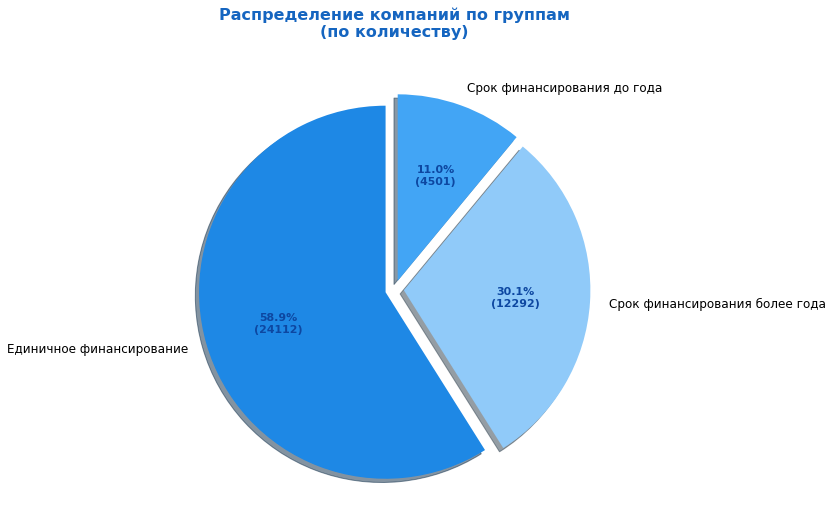

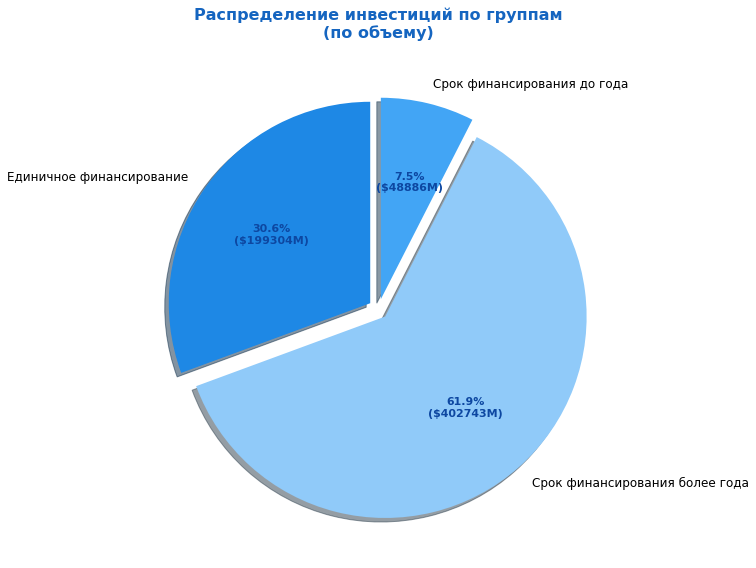

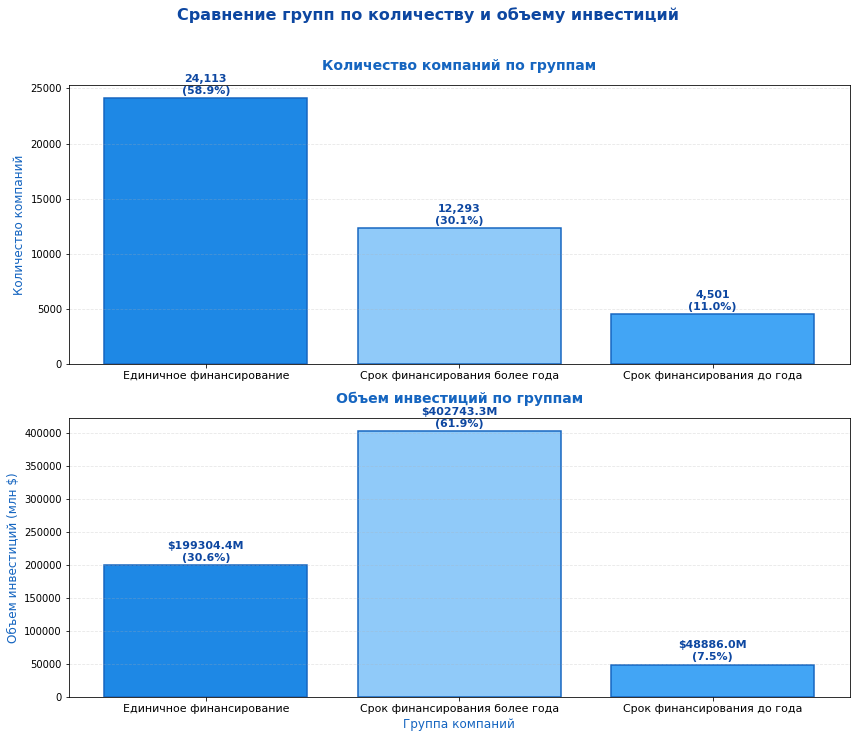

In [16]:
df_analysis = df_investments.copy()


def classify_funding_group(row):
    funding_rounds = row.get('funding_rounds', 0)
    if funding_rounds == 1:
        return 'Единичное финансирование'
    
    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        days_diff = (row['last_funding_at'] - row['first_funding_at']).days
        if days_diff <= 365:
            return 'Срок финансирования до года'
        else:
            return 'Срок финансирования более года'
    
    if funding_rounds > 1:
        return 'Срок финансирования более года'
    
    return 'Единичное финансирование'

df_analysis['funding_group'] = df_analysis.apply(classify_funding_group, axis=1)

print("Распределение компаний по группам:")
print(df_analysis['funding_group'].value_counts())
print(f"\nОбщее количество компаний: {len(df_analysis)}")

group_counts = df_analysis['funding_group'].value_counts()
group_percentages = (group_counts / len(df_analysis) * 100).round(1)

group_investments = df_analysis.groupby('funding_group')['funding_total_usd'].sum()
total_investments = df_analysis['funding_total_usd'].sum()
group_investment_percentages = (group_investments / total_investments * 100).round(1)

summary_df = pd.DataFrame({
    'Группа': group_counts.index,
    'Количество компаний': group_counts.values,
    '% компаний': group_percentages.values,
    'Объем инвестиций (млн $)': (group_investments.values / 1e6).round(1),
    '% инвестиций': group_investment_percentages.values
})

print("СТАТИСТИКА ПО ГРУППАМ:")
print(summary_df.to_string(index=False))

color_palette = {
    'Единичное финансирование': '#1E88E5',     
    'Срок финансирования до года': '#42A5F5',   
    'Срок финансирования более года': '#90CAF9' }

colors = [color_palette[group] for group in group_counts.index]

# 1 - количество компаний

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    group_counts.values,
    labels=group_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*len(df_analysis))})',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    textprops={'fontsize': 12},
    shadow=True
)

plt.title('Распределение компаний по группам\n(по количеству)', fontsize=16, fontweight='bold', pad=20, color='#1565C0')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('#0D47A1')

plt.tight_layout()
plt.show()

# 2- объем инвестиций

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    group_investments.values,
    labels=group_counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n(${pct/100*total_investments/1e6:.0f}M)',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    textprops={'fontsize': 12},
    shadow=True
)

plt.title('Распределение инвестиций по группам\n(по объему)', fontsize=16, fontweight='bold', pad=20, color='#1565C0')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('#0D47A1')

plt.tight_layout()
plt.show()

# 3 - сравнение
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.patch.set_facecolor('white')


x_pos = range(len(group_counts.index))
bars1 = axes[0].bar(x_pos, group_counts.values, color=colors, edgecolor='#1565C0', linewidth=1.5)
axes[0].set_ylabel('Количество компаний', fontsize=12, color='#1565C0')
axes[0].set_title('Количество компаний по группам', fontsize=14, fontweight='bold', color='#1565C0', pad=15)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(group_counts.index, fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


for bar, count, pct in zip(bars1, group_counts.values, group_percentages.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(group_counts.values)*0.01, 
             f'{count:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#0D47A1')

investments_millions = group_investments.values / 1e6
bars2 = axes[1].bar(x_pos, investments_millions, color=colors, edgecolor='#1565C0', linewidth=1.5)
axes[1].set_ylabel('Объем инвестиций (млн $)', fontsize=12, color='#1565C0')
axes[1].set_xlabel('Группа компаний', fontsize=12, color='#1565C0')
axes[1].set_title('Объем инвестиций по группам', fontsize=14, fontweight='bold', color='#1565C0', pad=15)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(group_counts.index, fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)


for bar, inv, pct in zip(bars2, investments_millions, group_investment_percentages.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(investments_millions)*0.01, 
             f'${inv:.1f}M\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#0D47A1')

plt.suptitle('Сравнение групп по количеству и объему инвестиций', fontsize=16, fontweight='bold', y=1.02, color='#0D47A1')
plt.tight_layout()
plt.show()


ВЫВОДЫ:
По количеству компаний доминирует: Единичное финансирование (58.9%)
По объему инвестиций доминирует: Срок финансирования более года (61.9%)
Группа 'Единичное финансирование' лидирует по числу компаний, но не по объему инвестиций
Группа 'Срок финансирования более года' привлекает больше средств при меньшем количестве компаний

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

АНАЛИЗ СЕГМЕНТОВ РЫНКА
  Всего уникальных сегментов: 849
  Всего компаний: 40,907

 КАТЕГОРИЗАЦИЯ СЕГМЕНТОВ:
  Массовые сегменты (≥121 компаний): 54 сегментов
  Средние сегменты (35-120 компаний): 81 сегментов
  Нишевые сегменты (<35 компаний): 714 сегментов

РАСПРЕДЕЛЕНИЕ КОМПАНИЙ:
  Массовые сегменты: 33,344 компаний (81.5%)
  Средние сегменты: 5,069 компаний (12.4%)
  Нишевые сегменты: 2,494 компаний (6.1%)

 ТОП-10 САМЫХ ПОПУЛЯРНЫХ СЕГМЕНТОВ:
   1.  software                      4,190 компаний
   2.  biotechnology                 3,531 компаний
   3. no_market                      2,503 компаний
   4.  mobile                        1,852 компаний
   5.  e-commerce                    1,528 компаний
   6.  curated web                   1,404 компаний
   7.  enterprise software           1,190 компаний
   8.  health care                   1,128 компаний
   9.  clean technology              1,094 компаний
  10.  hardware + software           1,008 компаний


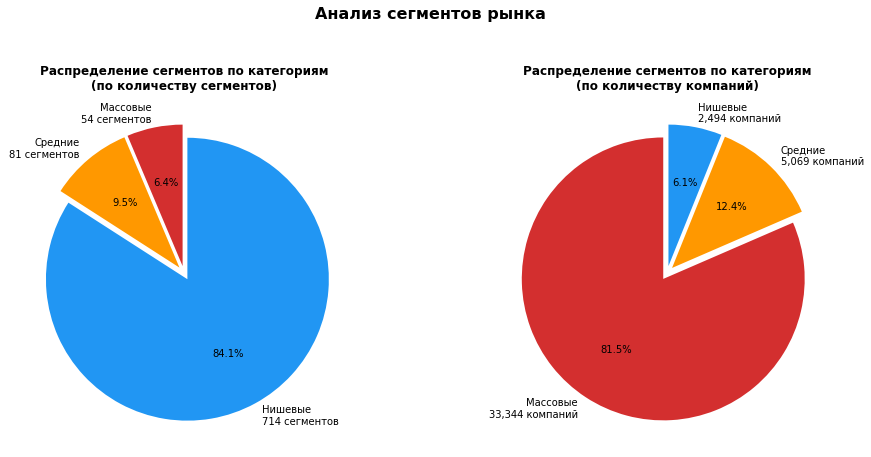

 МАССОВЫЕ СЕГМЕНТЫ:
   1.  software                           4,190 компаний
   2.  biotechnology                      3,531 компаний
   3. no_market                           2,503 компаний
   4.  mobile                             1,852 компаний
   5.  e-commerce                         1,528 компаний
   6.  curated web                        1,404 компаний
   7.  enterprise software                1,190 компаний
   8.  health care                        1,128 компаний
   9.  clean technology                   1,094 компаний
  10.  hardware + software                1,008 компаний
  11.  games                                986 компаний
  12.  advertising                          954 компаний
  13.  health and wellness                  825 компаний
  14.  social media                         787 компаний
  15.  education                            736 компаний
  16.  finance                              728 компаний
  17.  analytics                            565 компаний
  18.  manu

In [17]:
market_counts = df_investments['market'].value_counts()
total_segments = len(market_counts)
total_companies = market_counts.sum()

print("АНАЛИЗ СЕГМЕНТОВ РЫНКА")
print(f"  Всего уникальных сегментов: {total_segments}")
print(f"  Всего компаний: {total_companies:,}")

massive_threshold = 121
medium_threshold = 35
massive_segments = market_counts[market_counts >= massive_threshold]
medium_segments = market_counts[(market_counts >= medium_threshold) & (market_counts < massive_threshold)]
niche_segments = market_counts[market_counts < medium_threshold]

print(f"\n КАТЕГОРИЗАЦИЯ СЕГМЕНТОВ:")
print(f"  Массовые сегменты (≥121 компаний): {len(massive_segments)} сегментов")
print(f"  Средние сегменты (35-120 компаний): {len(medium_segments)} сегментов")
print(f"  Нишевые сегменты (<35 компаний): {len(niche_segments)} сегментов")

# Количество компаний в каждой категории
massive_companies = massive_segments.sum()
medium_companies = medium_segments.sum()
niche_companies = niche_segments.sum()

print(f"\nРАСПРЕДЕЛЕНИЕ КОМПАНИЙ:")
print(f"  Массовые сегменты: {massive_companies:,} компаний ({massive_companies/total_companies*100:.1f}%)")
print(f"  Средние сегменты: {medium_companies:,} компаний ({medium_companies/total_companies*100:.1f}%)")
print(f"  Нишевые сегменты: {niche_companies:,} компаний ({niche_companies/total_companies*100:.1f}%)")

print(f"\n ТОП-10 САМЫХ ПОПУЛЯРНЫХ СЕГМЕНТОВ:")
top10 = market_counts.head(10)
for i, (segment, count) in enumerate(top10.items(), 1):
    print(f"  {i:2d}. {segment:<30} {count:>5,} компаний")


# График 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# По количеству сегментов
segments_counts = [len(massive_segments), len(medium_segments), len(niche_segments)]
segments_labels = [f'Массовые\n{len(massive_segments)} сегментов', 
                   f'Средние\n{len(medium_segments)} сегментов', 
                   f'Нишевые\n{len(niche_segments)} сегментов']
segments_colors = ['#D32F2F', '#FF9800', '#2196F3']

ax1.pie(segments_counts, labels=segments_labels, colors=segments_colors, 
        autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax1.set_title('Распределение сегментов по категориям\n(по количеству сегментов)', fontsize=12, fontweight='bold')

companies_counts = [massive_companies, medium_companies, niche_companies]
companies_labels = [f'Массовые\n{massive_companies:,} компаний', 
                    f'Средние\n{medium_companies:,} компаний', 
                    f'Нишевые\n{niche_companies:,} компаний']

ax2.pie(companies_counts, labels=companies_labels, colors=segments_colors, 
        autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax2.set_title('Распределение сегментов по категориям\n(по количеству компаний)', fontsize=12, fontweight='bold')

plt.suptitle('Анализ сегментов рынка', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


print(" МАССОВЫЕ СЕГМЕНТЫ:")
for i, (segment, count) in enumerate(massive_segments.items(), 1):
    print(f"  {i:2d}. {segment:<35} {count:>5,} компаний")


ИТОГОВЫЙ ВЫВОД:

- Большинство сегментов (714 из 849, 84.1%) являются нишевыми.
- Однако именно массовые сегменты (всего 54 сегментов) концентрируют 81.5% всех компаний.
- Средние сегменты составляют 81 сегментов и содержат 12.4% компаний.

Теперь оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполнять будем с учётом этой замены.



Распределение по категориям:
Массовый сегмент    33344
Средний сегмент      5069
Нишевый сегмент      2494
Name: market_tier_name, dtype: int64
  ... и еще 44 массовых сегментов

Средние сегменты (объединены в 'Средний сегмент'):
  Количество сегментов: 81
  Всего компаний: 5,069

Нишевые сегменты (объединены в 'Нишевый сегмент'):
  Количество сегментов: 714
  Всего компаний: 2,494


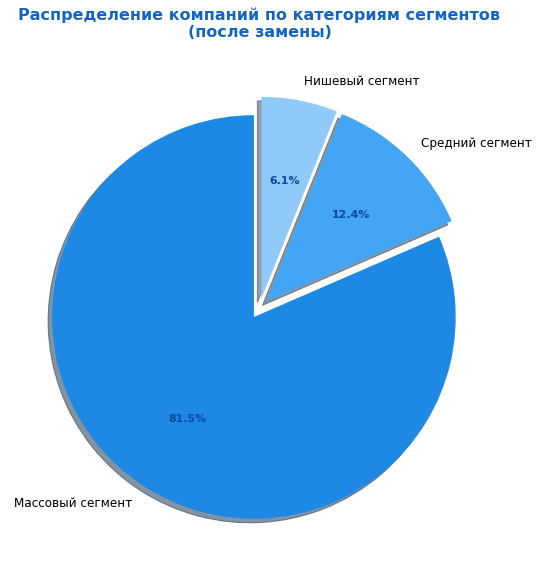

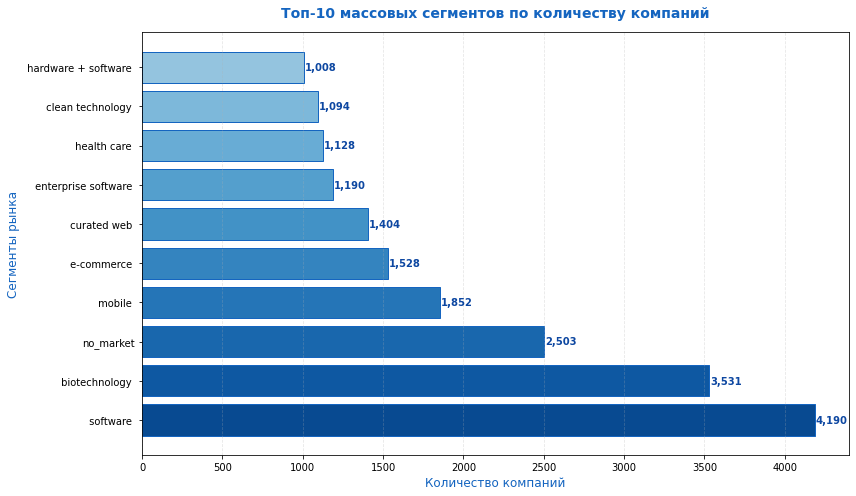

In [18]:
massive_threshold = 121
market_counts = df_investments['market'].value_counts()
massive_segments_list = market_counts[market_counts >= massive_threshold].index.tolist()

df_investments['market_category'] = df_investments['market'].copy()

df_investments.loc[~df_investments['market'].isin(massive_segments_list), 'market_category'] = 'other'

medium_threshold = 35
medium_segments_list = market_counts[(market_counts >= medium_threshold) & (market_counts < massive_threshold)].index.tolist()
niche_segments_list = market_counts[market_counts < medium_threshold].index.tolist()

df_investments['market_tier'] = 'massive'
df_investments.loc[df_investments['market'].isin(medium_segments_list), 'market_tier'] = 'mid'
df_investments.loc[df_investments['market'].isin(niche_segments_list), 'market_tier'] = 'niche'

tier_names = {
    'massive': 'Массовый сегмент',
    'mid': 'Средний сегмент',
    'niche': 'Нишевый сегмент'
}
df_investments['market_tier_name'] = df_investments['market_tier'].map(tier_names)


print(f"\nРаспределение по категориям:")
print(df_investments['market_tier_name'].value_counts())

if len(massive_segments_list) > 10:
    print(f"  ... и еще {len(massive_segments_list) - 10} массовых сегментов")

print(f"\nСредние сегменты (объединены в 'Средний сегмент'):")
print(f"  Количество сегментов: {len(medium_segments_list)}")
print(f"  Всего компаний: {df_investments[df_investments['market_tier'] == 'mid'].shape[0]:,}")

print(f"\nНишевые сегменты (объединены в 'Нишевый сегмент'):")
print(f"  Количество сегментов: {len(niche_segments_list)}")
print(f"  Всего компаний: {df_investments[df_investments['market_tier'] == 'niche'].shape[0]:,}")


plt.figure(figsize=(10, 8))

tier_counts = df_investments['market_tier_name'].value_counts()
colors_tier = {
    'Массовый сегмент': '#1E88E5',   
    'Средний сегмент': '#42A5F5',
    'Нишевый сегмент': '#90CAF9'      
}
pie_colors = [colors_tier[tier] for tier in tier_counts.index]

wedges, texts, autotexts = plt.pie(
    tier_counts.values, 
    labels=tier_counts.index, 
    colors=pie_colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('#0D47A1')

plt.title('Распределение компаний по категориям сегментов\n(после замены)', fontsize=16, fontweight='bold', pad=20, color='#1565C0')
plt.tight_layout()
plt.show()


massive_df = df_investments[df_investments['market_tier'] == 'massive']
massive_top10 = massive_df['market'].value_counts().head(10)

plt.figure(figsize=(12, 7))


colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(massive_top10)))[::-1]

bars = plt.barh(range(len(massive_top10)), massive_top10.values, color=colors_gradient, edgecolor='#1565C0', linewidth=1)

plt.ylabel('Сегменты рынка', fontsize=12, color='#1565C0')
plt.xlabel('Количество компаний', fontsize=12, color='#1565C0')
plt.title('Топ-10 массовых сегментов по количеству компаний', fontsize=14, fontweight='bold', pad=15, color='#1565C0')
plt.yticks(range(len(massive_top10)), massive_top10.index, fontsize=10)

for bar, count in zip(bars, massive_top10.values):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=10, fontweight='bold', color='#0D47A1')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


ИТОГОВАЯ СТАТИСТИКА:
 Массовых сегментов: 54 сегментов
   - Содержат 33,344 компаний (81.5%)

Средних сегментов: 81 сегментов (объединены)
   - Содержат 5,069 компаний (12.4%)
 Нишевых сегментов: 714 сегментов (объединены)
   - Содержат 2,494 компаний (6.1%)

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.


 ОСНОВНАЯ СТАТИСТИКА (в млн $):
  Количество компаний: 40,907
  Минимум: $0.00M
  Максимум: $30079.50M
  Среднее: $15.91M
  Медиана: $2.00M

 КВАРТИЛИ (в млн $):
  25-й перцентиль (Q1): $0.35M
  50-й перцентиль (Q2/медиана): $2.00M
  75-й перцентиль (Q3): $10.00M

ТИПИЧНЫЙ ИНТЕРВАЛ (межквартильный размах):
  От $0.35M до $10.00M
  Это интервал, в котором находятся 50% всех компаний

ВЫБИВАЮЩИЕСЯ ЗНАЧЕНИЯ:
  Верхняя граница: $24.48M
  Компаний-выбросов: 5,232 (12.79%)


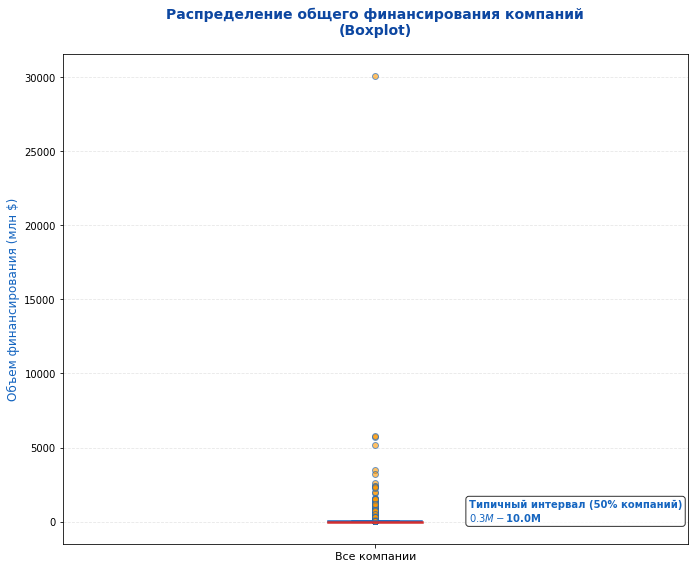

In [19]:
funding = df_investments['funding_total_usd'].dropna()
print(f"\n ОСНОВНАЯ СТАТИСТИКА (в млн $):")
print(f"  Количество компаний: {len(funding):,}")
print(f"  Минимум: ${funding.min()/1e6:.2f}M")
print(f"  Максимум: ${funding.max()/1e6:.2f}M")
print(f"  Среднее: ${funding.mean()/1e6:.2f}M")
print(f"  Медиана: ${funding.median()/1e6:.2f}M")

q1 = funding.quantile(0.25)
q2 = funding.quantile(0.50)
q3 = funding.quantile(0.75)

print(f"\n КВАРТИЛИ (в млн $):")
print(f"  25-й перцентиль (Q1): ${q1/1e6:.2f}M")
print(f"  50-й перцентиль (Q2/медиана): ${q2/1e6:.2f}M")
print(f"  75-й перцентиль (Q3): ${q3/1e6:.2f}M")


typical_lower = q1
typical_upper = q3
print(f"\nТИПИЧНЫЙ ИНТЕРВАЛ (межквартильный размах):")
print(f"  От ${typical_lower/1e6:.2f}M до ${typical_upper/1e6:.2f}M")
print(f"  Это интервал, в котором находятся 50% всех компаний")


iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = funding[funding > upper_bound]
print(f"\nВЫБИВАЮЩИЕСЯ ЗНАЧЕНИЯ:")
print(f"  Верхняя граница: ${upper_bound/1e6:.2f}M")
print(f"  Компаний-выбросов: {len(outliers):,} ({len(outliers)/len(funding)*100:.2f}%)")


plt.figure(figsize=(10, 8))
box = plt.boxplot(funding / 1e6, 
                   vert=True, 
                   patch_artist=True,
                   boxprops=dict(facecolor='#42A5F5', color='#1565C0', linewidth=1.5),
                   whiskerprops=dict(color='#1565C0', linewidth=1.5),
                   capprops=dict(color='#1565C0', linewidth=1.5),
                   medianprops=dict(color='#D32F2F', linewidth=2.5),
                   flierprops=dict(marker='o', markerfacecolor='#FF9800', 
                                   markersize=6, alpha=0.6, markeredgecolor='#1565C0'))

plt.ylabel('Объем финансирования (млн $)', fontsize=12, color='#1565C0')
plt.title('Распределение общего финансирования компаний\n(Boxplot)', fontsize=14, fontweight='bold', color='#0D47A1', pad=20)
plt.xticks([1], ['Все компании'], fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Добавляем аннотацию с типичным интервалом
plt.annotate(f'Типичный интервал (50% компаний)\n${typical_lower/1e6:.1f}M - ${typical_upper/1e6:.1f}M',
             xy=(1, typical_upper/1e6), 
             xytext=(1.15, typical_upper/1e6),
             fontsize=10, 
             ha='left', 
             color='#1565C0', 
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


ТИПИЧНЫЙ РАЗМЕР ФИНАНСИРОВАНИЯ:
-Интервал: от 0,35 М $ до 10 M $ это межквартильный размах (IQR), в котором находятся 50% всех компаний.
-Медианное значение составляет 2 М $.
Выбивающиеся значения:

-Компании с финансированием более 24,46 М $ считаются выбросами. Таких компаний 5,232 (12.79% от общего числа).

ОСОБЕННОСТИ РАСПРЕДЕЛЕНИЯ:
   • Распределение имеет сильный положительный скос (правый хвост)
   
   • Среднее (15,91 М $) значительно выше медианы (2М $)
   
   • Это указывает на наличие небольшого числа компаний с очень крупным финансированием
   
   • Для анализа типичных значений рекомендуется использовать медиану и IQR

Определим компании с аномальным объёмом общего финансирования — используя метод IQR отдельно по каждому сегменту. Все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

  Всего компаний: 40,907
  Компаний с аномальным финансированием: 5,202 (12.72%)
  Количество анализируемых сегментов: 56
 ТОП-15 СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ АНОМАЛЬНОГО ФИНАНСИРОВАНИЯ
   1.  real estate                             45.0 компаний ( 17.9%)
   2.  technology                              37.0 компаний ( 16.2%)
   3.  search                                  39.0 компаний ( 16.1%)
   4. software                                 22.0 компаний ( 16.1%)
   5.  entertainment                           22.0 компаний ( 16.1%)
   6.  cloud computing                         21.0 компаний ( 16.0%)
   7.  big data                                22.0 компаний ( 15.7%)
   8.  saas                                    35.0 компаний ( 15.6%)
   9. e-commerce                               20.0 компаний ( 15.5%)
  10.  travel                                  45.0 компаний ( 15.4%)
  11.  marketplaces                            27.0 компаний ( 15.3%)
  12.  video                                

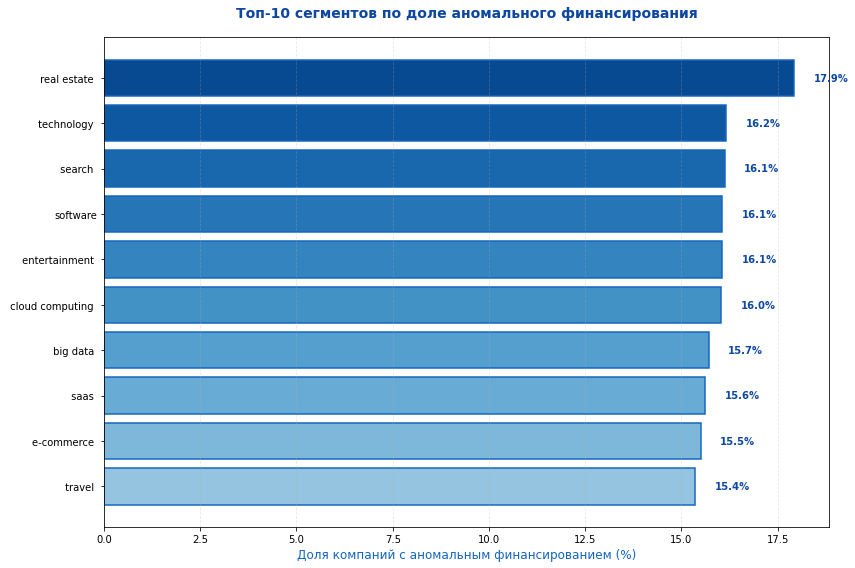

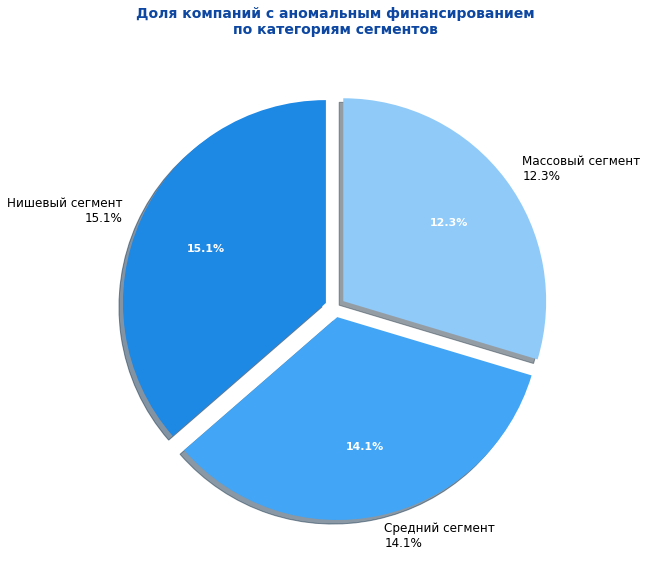

In [20]:
df_analysis = df_investments.copy()

df_analysis['segment_for_analysis'] = df_analysis['market_tier_name'].copy()

massive_mask = df_analysis['market_tier'] == 'massive'
df_analysis.loc[massive_mask, 'segment_for_analysis'] = df_analysis.loc[massive_mask, 'market']

def detect_outliers_iqr(data):
    """Возвращает boolean массив, где True - выброс"""
    if len(data) < 5: 
        return pd.Series([False] * len(data))
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (data < lower_bound) | (data > upper_bound)


df_analysis['is_outlier'] = df_analysis.groupby('segment_for_analysis')['funding_total_usd'].transform(
    lambda x: detect_outliers_iqr(x))
segment_stats = df_analysis.groupby('segment_for_analysis').agg({
    'funding_total_usd': ['count', 'median', 'mean', 'std'],
    'is_outlier': 'sum'
}).round(2)

segment_stats.columns = ['count', 'median_usd', 'mean_usd', 'std_usd', 'outliers_count']
segment_stats['outliers_pct'] = (segment_stats['outliers_count'] / segment_stats['count'] * 100).round(2)
segment_stats = segment_stats.sort_values('outliers_pct', ascending=False)

segment_stats['median_usd'] = segment_stats['median_usd'] / 1e6
segment_stats['mean_usd'] = segment_stats['mean_usd'] / 1e6
segment_stats['std_usd'] = segment_stats['std_usd'] / 1e6

print(f"  Всего компаний: {len(df_analysis):,}")
print(f"  Компаний с аномальным финансированием: {df_analysis['is_outlier'].sum():,} ({df_analysis['is_outlier'].sum()/len(df_analysis)*100:.2f}%)")
print(f"  Количество анализируемых сегментов: {df_analysis['segment_for_analysis'].nunique()}")

print(" ТОП-15 СЕГМЕНТОВ С НАИБОЛЬШЕЙ ДОЛЕЙ АНОМАЛЬНОГО ФИНАНСИРОВАНИЯ")

top_outlier_segments = segment_stats.head(15)
for idx, (segment, row) in enumerate(top_outlier_segments.iterrows(), 1):
    segment_type = ""
    if segment in ['Массовый сегмент', 'Средний сегмент', 'Нишевый сегмент']:
        segment_type = " [обобщенный]"
    print(f"  {idx:2d}. {segment:<40} {row['outliers_count']:>4} компаний ({row['outliers_pct']:>5.1f}%){segment_type}")

# 1 Топ-10 сегментов по доле аномалий 
plt.figure(figsize=(12, 8))
top10 = top_outlier_segments.head(10)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top10)))[::-1]

bars = plt.barh(range(len(top10)), top10['outliers_pct'].values, color=colors, edgecolor='#1565C0', linewidth=1.5)
plt.yticks(range(len(top10)), top10.index, fontsize=10)
plt.xlabel('Доля компаний с аномальным финансированием (%)', fontsize=12, color='#1565C0')
plt.title('Топ-10 сегментов по доле аномального финансирования', fontsize=14, fontweight='bold', color='#0D47A1', pad=20)
plt.gca().invert_yaxis()

for bar, pct in zip(bars, top10['outliers_pct'].values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold', color='#0D47A1')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#  2 - сравнение доли аномалий по категориям сегментов

category_outliers = df_analysis.groupby('market_tier_name')['is_outlier'].agg(['sum', 'count'])
category_outliers['pct'] = (category_outliers['sum'] / category_outliers['count'] * 100).round(1)

category_outliers = category_outliers.sort_values('pct', ascending=False)

colors_pie = ['#1E88E5', '#42A5F5', '#90CAF9']

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    category_outliers['pct'].values,
    labels=[f'{cat}\n{val:.1f}%' for cat, val in zip(category_outliers.index, category_outliers['pct'].values)],
    colors=colors_pie[:len(category_outliers)],
    autopct='',
    startangle=90,
    explode=(0.05, 0.05, 0.05),
    shadow=True,
    textprops={'fontsize': 12}
)

for i, (wedge, pct) in enumerate(zip(wedges, category_outliers['pct'].values)):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.7 * np.cos(np.radians(angle))
    y = 0.7 * np.sin(np.radians(angle))
    plt.text(x, y, f'{pct:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Доля компаний с аномальным финансированием\nпо категориям сегментов', fontsize=14, fontweight='bold', color='#0D47A1', pad=20)
plt.tight_layout()
plt.show()


Сегмент с НАИБОЛЬШЕЙ долей аномального финансирования: real estate : 17.9% компаний (45.0 из 251.0)
Другие сегменты в топ-3:
   2.  technology : 16.2%
   3.  search : 16.1%
По категориям сегментов:
   Массовый сегмент: 12.3% компаний с аномальным финансированием
   Средний сегмент: 14.1% компаний с аномальным финансированием
   Нишевый сегмент: 15.1% компаний с аномальным финансированием


При анализе инвестиционного климата и темпов роста по рынкам стоит учитывать, что ряд сегментов из топа по выбросам не всегда подходит для расчёта "средней температуры по больнице". Компании с аномально большими инвестициями могут искусственно увеличивать значения суммарного финансирования и искажать выводы о реальном положении дел на отраслевом уровне.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Когда исключим аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.


 Данные за 2014 год присутствуют: 11915 компаний
   2013 год: 8687 компаний
   2014 год: 11915 компаний
   2015 год: 0 компаний

 2014 год ПОЛНЫЙ (составляет 274.3% от среднего за 2013-2015)


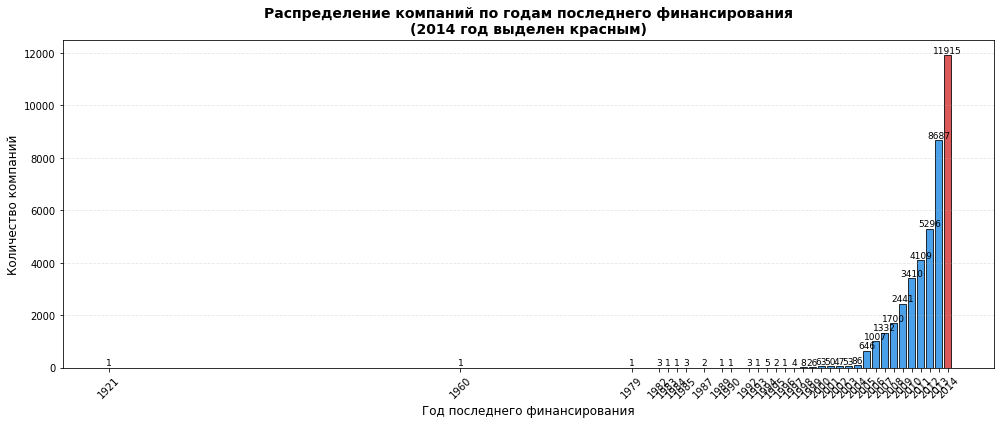

Выполняем обнаружение выбросов...

 До фильтраций аномалий:
  Всего компаний: 40,907
  Компаний с аномальным финансированием: 5,428 (13.27%)

 После фильтраций аномалий:
  Всего компаний: 35,479
  Исключено: 5,428 компаний

 Годы с 50+ раундами финансирования: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

 После фильтрации по годам:
  До фильтрации: 35,479 компаний
  После фильтрации: 35,432 компаний
  Исключено: 47 компаний


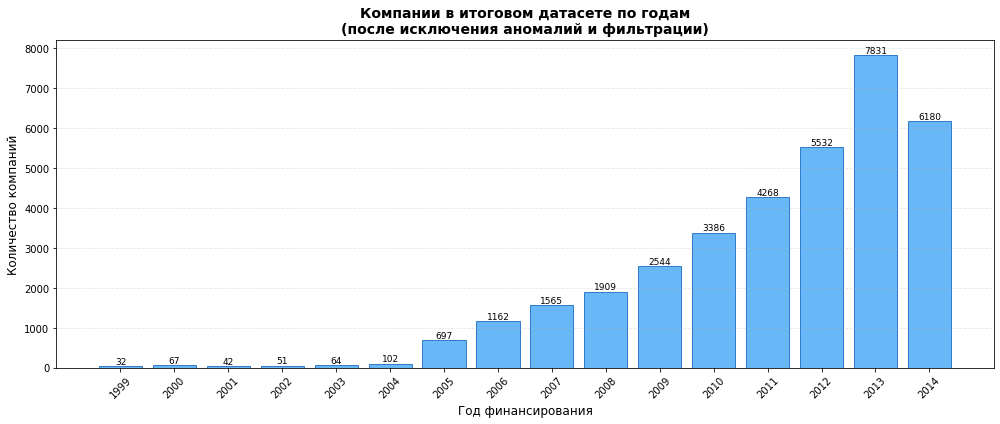


  Исходное количество компаний: 40,907
 Исключено аномальных компаний: 5,428
  Исключено компаний не в годы с 50+ раундами: 47
  
 ИТОГОВОЕ КОЛИЧЕСТВО КОМПАНИЙ: 35,432
  
 Годы с 50+ раундами: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]



In [21]:
if 'last_funding_year' not in df_investments.columns:
    df_investments['last_funding_year'] = df_investments['last_funding_at'].dt.year

funding_by_year = df_investments.groupby('last_funding_year').size().sort_index()

if 2014 in funding_by_year.index:
    print(f"\n Данные за 2014 год присутствуют: {funding_by_year[2014]} компаний")
    prev_year = funding_by_year.get(2013, 0)
    next_year = funding_by_year.get(2015, 0)
    print(f"   2013 год: {prev_year} компаний")
    print(f"   2014 год: {funding_by_year[2014]} компаний")
    print(f"   2015 год: {next_year} компаний")
    
    avg_neighbors = (prev_year + next_year) / 2
    ratio_2014 = funding_by_year[2014] / avg_neighbors if avg_neighbors > 0 else 1
    
    if ratio_2014 < 0.7:
        print(f"\n 2014 год НЕПОЛНЫЙ")
        print(f"   Количество компаний в 2014 составляет {ratio_2014:.1%} от среднего за 2013-2015")
    else:
        print(f"\n 2014 год ПОЛНЫЙ (составляет {ratio_2014:.1%} от среднего за 2013-2015)")
else:
    print("\n Данных за 2014 год нет")

# ГРАФИК Распределение компаний по годам последнего финансирования
plt.figure(figsize=(14, 6))
years = funding_by_year.index
counts = funding_by_year.values

colors = ['#1E88E5' if year != 2014 else '#D32F2F' for year in years]
bars = plt.bar(years, counts, color=colors, edgecolor='black', alpha=0.8)

plt.xlabel('Год последнего финансирования', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Распределение компаний по годам последнего финансирования\n(2014 год выделен красным)', fontsize=14, fontweight='bold')
plt.xticks(years, rotation=45)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

if 'is_outlier' not in df_investments.columns:
    print("Выполняем обнаружение выбросов...")
    
    def detect_outliers_iqr(data):
        if len(data) < 5:
            return pd.Series([False] * len(data))
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        return data > upper_bound
    
    df_investments['is_outlier'] = df_investments.groupby('market_tier_name')['funding_total_usd'].transform(
        lambda x: detect_outliers_iqr(x))

before_count = len(df_investments)
outliers_count = df_investments['is_outlier'].sum()

print(f"\n До фильтраций аномалий:")
print(f"  Всего компаний: {before_count:,}")
print(f"  Компаний с аномальным финансированием: {outliers_count:,} ({outliers_count/before_count*100:.2f}%)")

df_clean = df_investments[~df_investments['is_outlier']].copy()

after_count = len(df_clean)
print(f"\n После фильтраций аномалий:")
print(f"  Всего компаний: {after_count:,}")
print(f"  Исключено: {before_count - after_count:,} компаний")

if 'funding_year' not in df_clean.columns:
    if 'mid_funding_at' in df_clean.columns:
        df_clean['funding_year'] = df_clean['mid_funding_at'].dt.year
    else:
        df_clean['funding_year'] = df_clean['last_funding_at'].dt.year

rounds_by_year = df_clean.groupby('funding_year')['funding_rounds'].sum().fillna(0).astype(int)
rounds_by_year = rounds_by_year.sort_index()
valid_years = rounds_by_year[rounds_by_year >= 50].index.tolist()
print(f"\n Годы с 50+ раундами финансирования: {valid_years}")

# Оставляем только компании, которые получали финансирование в эти годы
before_filter = len(df_clean)
df_final = df_clean[df_clean['funding_year'].isin(valid_years)].copy()
after_filter = len(df_final)

print(f"\n После фильтрации по годам:")
print(f"  До фильтрации: {before_filter:,} компаний")
print(f"  После фильтрации: {after_filter:,} компаний")
print(f"  Исключено: {before_filter - after_filter:,} компаний")

# ГРАФИК Компании в итоговом датасете по годам
plt.figure(figsize=(14, 6))

final_by_year = df_final.groupby('funding_year').size()
years_final = final_by_year.index
counts_final = final_by_year.values

bars = plt.bar(years_final, counts_final, color='#42A5F5', edgecolor='#1565C0', alpha=0.8)
plt.xlabel('Год финансирования', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.title('Компании в итоговом датасете по годам\n(после исключения аномалий и фильтрации)', fontsize=14, fontweight='bold')
plt.xticks(years_final, rotation=45)

for bar, count in zip(bars, counts_final):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{count}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
  Исходное количество компаний: {before_count:,}
 Исключено аномальных компаний: {outliers_count:,}
  Исключено компаний не в годы с 50+ раундами: {before_filter - after_filter:,}
  
 ИТОГОВОЕ КОЛИЧЕСТВО КОМПАНИЙ: {len(df_final):,}
  
 Годы с 50+ раундами: {valid_years}
""")

# Сохраняем итоговый датасет для дальнейшего использования
df_cleaned_filtered = df_final

Так как в датасете есть данные о финансировании за последний день года и о компаниях, основанных в последний месяц года, считаем, что данные за 2014 год полные.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.


 ОБЪЕМ ФИНАНСИРОВАНИЯ ПО ТИПАМ (в млн $):
  venture                  : $   104,909.9M
  seed                     : $     9,572.2M
  debt_financing           : $     5,708.4M
  private_equity           : $     3,158.2M
  angel                    : $     2,600.7M
  undisclosed              : $     2,199.7M
  grant                    : $     1,898.2M
  post_ipo_equity          : $       982.3M
  convertible_note         : $       496.1M
  equity_crowdfunding      : $       278.7M
  product_crowdfunding     : $       210.1M
  post_ipo_debt            : $       127.8M
  secondary_market         : $        45.3M

 ПОПУЛЯРНОСТЬ ТИПОВ ФИНАНСИРОВАНИЯ (количество компаний):
  venture                  : 18,635 компаний ( 52.6%)
  seed                     : 13,468 компаний ( 38.0%)
  debt_financing           :  3,050 компаний (  8.6%)
  angel                    :  2,985 компаний (  8.4%)
  grant                    :  1,000 компаний (  2.8%)
  undisclosed              :    831 компаний (  2.3%)
  

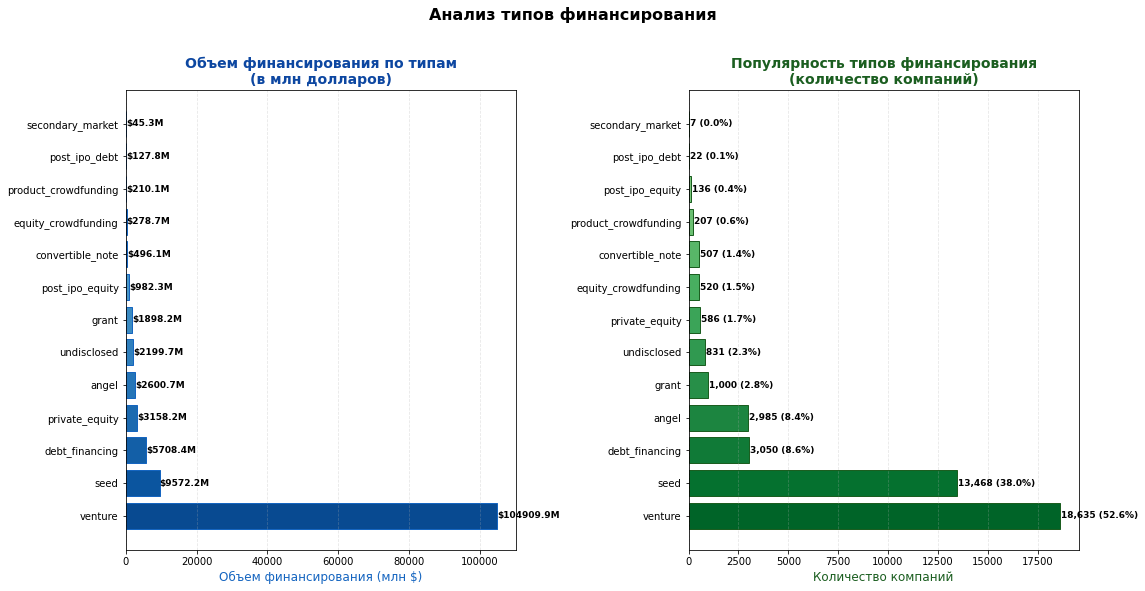

In [22]:
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding']

df_funding = df_final.copy()
sum_by_type = {}
for ft in funding_types:
    if ft in df_funding.columns:
        total = df_funding[ft].sum() / 1e6 
        sum_by_type[ft] = total

sum_by_type_sorted = dict(sorted(sum_by_type.items(), key=lambda x: x[1], reverse=True))

print("\n ОБЪЕМ ФИНАНСИРОВАНИЯ ПО ТИПАМ (в млн $):")
for ft, total in sum_by_type_sorted.items():
    print(f"  {ft:<25}: ${total:>12,.1f}M")

popularity_by_type = {}
for ft in funding_types:
    if ft in df_funding.columns:
        count = (df_funding[ft] > 0).sum()
        popularity_by_type[ft] = count

popularity_by_type_sorted = dict(sorted(popularity_by_type.items(), key=lambda x: x[1], reverse=True))

print("\n ПОПУЛЯРНОСТЬ ТИПОВ ФИНАНСИРОВАНИЯ (количество компаний):")
for ft, count in popularity_by_type_sorted.items():
    pct = count / len(df_funding) * 100
    print(f"  {ft:<25}: {count:>6,} компаний ({pct:>5.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('white')

# ГРАФИК  Объем финансирования по типам
ax1 = axes[0]
types1 = list(sum_by_type_sorted.keys())
values1 = list(sum_by_type_sorted.values())

colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(types1)))[::-1]

bars1 = ax1.barh(range(len(types1)), values1, color=colors1, edgecolor='#1565C0', linewidth=1)
ax1.set_yticks(range(len(types1)))
ax1.set_yticklabels(types1, fontsize=10)
ax1.set_xlabel('Объем финансирования (млн $)', fontsize=12, color='#1565C0')
ax1.set_title('Объем финансирования по типам\n(в млн долларов)', fontsize=14, fontweight='bold', color='#0D47A1')

for bar, val in zip(bars1, values1):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'${val:.1f}M', ha='left', va='center', fontsize=9, fontweight='bold')

ax1.grid(axis='x', linestyle='--', alpha=0.3)

# ГРАФИК  Популярность типов финансирования
ax2 = axes[1]
types2 = list(popularity_by_type_sorted.keys())
values2 = list(popularity_by_type_sorted.values())
pcts2 = [v / len(df_funding) * 100 for v in values2]

colors2 = plt.cm.Greens(np.linspace(0.4, 0.9, len(types2)))[::-1]

bars2 = ax2.barh(range(len(types2)), values2, color=colors2, edgecolor='#1B5E20', linewidth=1)
ax2.set_yticks(range(len(types2)))
ax2.set_yticklabels(types2, fontsize=10)
ax2.set_xlabel('Количество компаний', fontsize=12, color='#1B5E20')
ax2.set_title('Популярность типов финансирования\n(количество компаний)', fontsize=14, fontweight='bold', color='#1B5E20')

for bar, val, pct in zip(bars2, values2, pcts2):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
             f'{val:,} ({pct:.1f}%)', ha='left', va='center', fontsize=9, fontweight='bold')

ax2.grid(axis='x', linestyle='--', alpha=0.3)

plt.suptitle('Анализ типов финансирования', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



ЧАСТО ИСПОЛЬЗУЕМЫЕ, НО С НЕБОЛЬШИМ ОБЪЕМОМ:
  • grant: $ 1898.2M, 1,000 компаний

 РЕДКО ИСПОЛЬЗУЕМЫЕ, НО С БОЛЬШИМ ОБЪЕМОМ:
  • private_equity: $3158.2M, 586 компаний

 ЧАСТО ИСПОЛЬЗУЕМЫЕ И С БОЛЬШИМ ОБЪЕМОМ (лидеры):
  • venture: $ 104909.9M, 18,635 компаний
  • seed: $ 9572.2M, 13,468 компаний
  • debt_financing: $ 5708.4M, 3,050 компаний
  • angel: $ 2600.7M, 2,985 компаний
  • undisclosed: $ 2199.7M, 831 компаний
  
ЛИДЕРЫ ПО ОБЪЕМУ И ПОПУЛЯРНОСТИ: venture, seed, debt_financing, angel, undisclosed


Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.


 СУММАРНЫЕ ВОЗВРАТЫ ПО ТИПАМ ФИНАНСИРОВАНИЯ (в млн $):
  venture                  : $    40,578.6M
  debt_financing           : $     4,734.9M
  private_equity           : $     3,587.3M
  seed                     : $     2,382.2M
  angel                    : $     1,509.2M
  post_ipo_equity          : $     1,105.0M
  undisclosed              : $       730.9M
  post_ipo_debt            : $        91.0M
  convertible_note         : $        34.8M
  secondary_market         : $         5.2M
  equity_crowdfunding      : $         3.8M
  product_crowdfunding     : $         1.9M
  grant                    : $         0.0M

 ОБЩАЯ СУММА ВОЗВРАТОВ: $54,764.8M


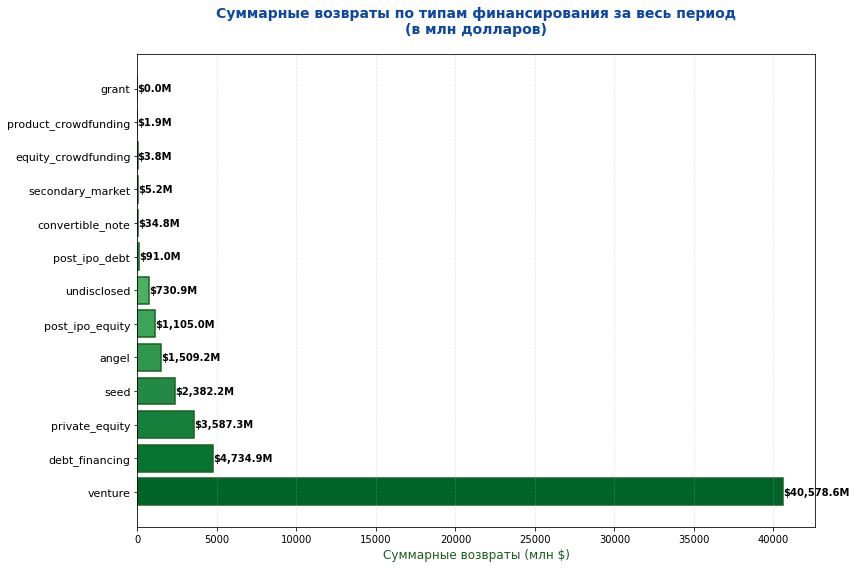

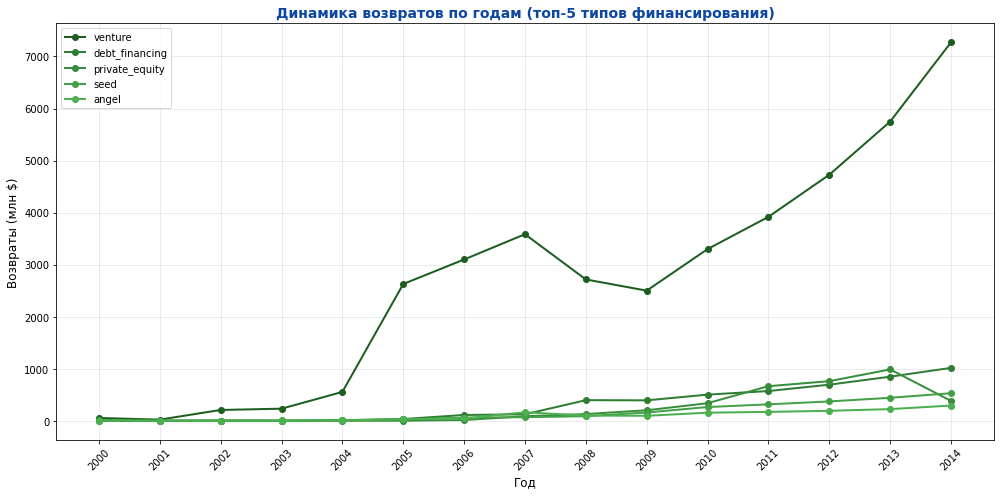

In [23]:
return_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'secondary_market', 'product_crowdfunding' ]
for col in ['post_ipo_equity', 'post_ipo_debt']:
    if col in df_returns.columns:
        return_types.append(col)

total_returns = {}
for rt in return_types:
    if rt in df_returns.columns:
        total = df_returns[rt].sum()
        total_returns[rt] = total

total_returns_sorted = dict(sorted(total_returns.items(), key=lambda x: x[1], reverse=True))
print("\n СУММАРНЫЕ ВОЗВРАТЫ ПО ТИПАМ ФИНАНСИРОВАНИЯ (в млн $):")
for rt, total in total_returns_sorted.items():
    print(f"  {rt:<25}: ${total:>12,.1f}M")

total_all_returns = sum(total_returns.values())
print(f"\n ОБЩАЯ СУММА ВОЗВРАТОВ: ${total_all_returns:,.1f}M")

# график  гистограмма суммарных возвратов
plt.figure(figsize=(12, 8))

types = list(total_returns_sorted.keys())
values = list(total_returns_sorted.values())
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(types)))[::-1]

bars = plt.barh(range(len(types)), values, color=colors, edgecolor='#1B5E20', linewidth=1.5)
plt.yticks(range(len(types)), types, fontsize=11)
plt.xlabel('Суммарные возвраты (млн $)', fontsize=12, color='#1B5E20')
plt.title('Суммарные возвраты по типам финансирования за весь период\n(в млн долларов)', fontsize=14, fontweight='bold', color='#0D47A1', pad=20)

for bar, val in zip(bars, values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'${val:,.1f}M', ha='left', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# график Динамика возвратов по годам (топ-5 типов)
plt.figure(figsize=(14, 7))
top5_types = list(total_returns_sorted.keys())[:5]

colors_line = ['#1B5E20', '#2E7D32', '#388E3C', '#43A047', '#4CAF50']
for i, rt in enumerate(top5_types):
    if rt in df_returns.columns:
        plt.plot(df_returns.index, df_returns[rt].values, 'o-', 
                 color=colors_line[i], linewidth=2, markersize=6, label=rt)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Возвраты (млн $)', fontsize=12)
plt.title('Динамика возвратов по годам (топ-5 типов финансирования)', fontsize=14, fontweight='bold', color='#0D47A1')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(df_returns.index, rotation=45)

plt.tight_layout()
plt.show()


Максимальный возврат: venture: $ 40,578.6M
        
 - Топ-3 типа составляют 89.3% всех возвратов
 - 12 из 13 типов имеют ненулевые возвраты
 - Пик возвратов пришелся на 2014 год
 - Минимум возвратов был в 2001 году

venture лидирует по объёму возвращённых средств, а вот находившийся в тройке лидеров и по объёму и по количеству предоставленных средств seed перешёл на четвёртое место по возвратам.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будем строить графики в этом задании и следующих, будем использовать данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

   Компаний с нулевым финансированием: 0
   Компаний с funding_rounds = 0: 0
   Компаний для анализа после очистки: 35,432

 СТАТИСТИКА СРЕДНЕГО РАЗМЕРА РАУНДА (в млн $):
   Медиана: $0.99M
   Среднее: $2.45M


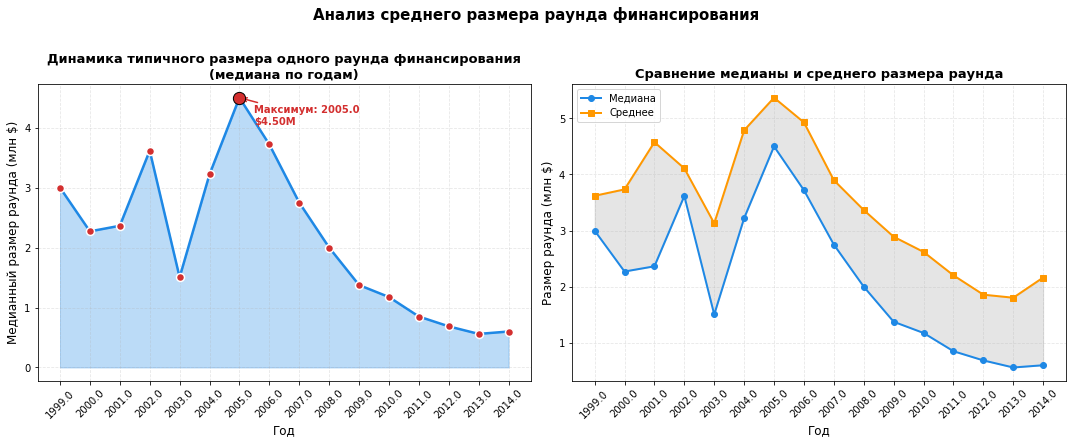

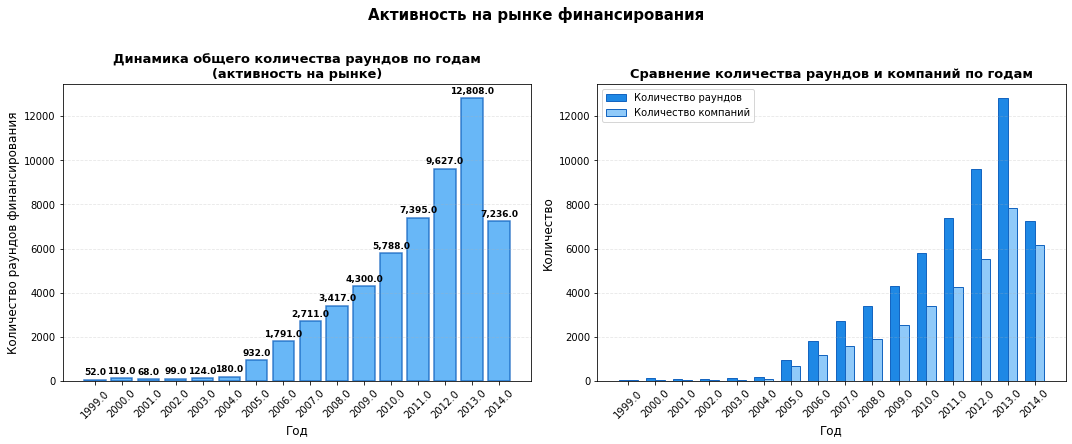

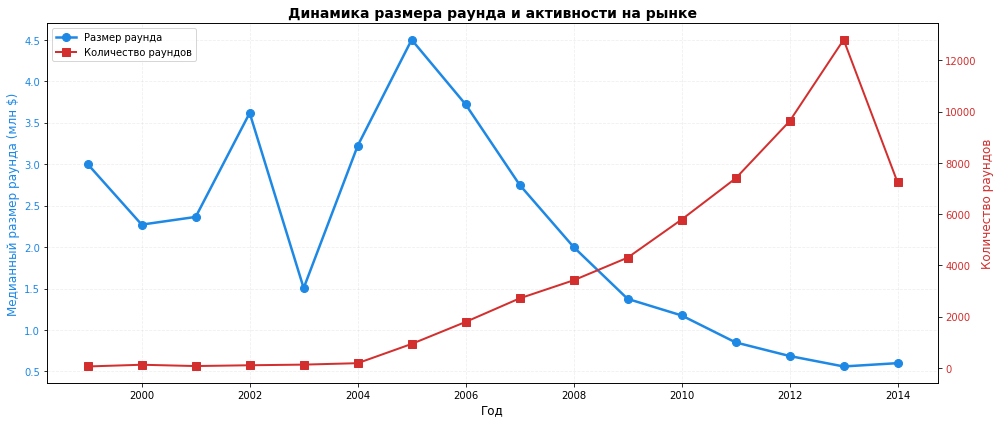

 2005.0 год ($4.50M)
   • Размер раунда: РОСТ ($0.56M → $0.60M)
   • Количество раундов: СНИЖЕНИЕ (12,808.0 → 7,236.0)


In [24]:
df_analysis = df_final.copy()
df_analysis['avg_round_size'] = df_analysis['funding_total_usd'] / df_analysis['funding_rounds']

print(f"   Компаний с нулевым финансированием: {(df_analysis['funding_total_usd'] == 0).sum()}")
print(f"   Компаний с funding_rounds = 0: {(df_analysis['funding_rounds'] == 0).sum()}")
df_clean_rounds = df_analysis[(df_analysis['funding_rounds'] > 0) & (df_analysis['funding_total_usd'] > 0)].copy()
print(f"   Компаний для анализа после очистки: {len(df_clean_rounds):,}")

print(f"\n СТАТИСТИКА СРЕДНЕГО РАЗМЕРА РАУНДА (в млн $):")
avg_round_median = df_clean_rounds['avg_round_size'].median() / 1e6
avg_round_mean = df_clean_rounds['avg_round_size'].mean() / 1e6
print(f"   Медиана: ${avg_round_median:.2f}M")
print(f"   Среднее: ${avg_round_mean:.2f}M")

if 'funding_year' not in df_clean_rounds.columns:
    if 'mid_funding_at' in df_clean_rounds.columns:
        df_clean_rounds['funding_year'] = df_clean_rounds['mid_funding_at'].dt.year
    else:
        df_clean_rounds['funding_year'] = df_clean_rounds['last_funding_at'].dt.year

yearly_avg_round = df_clean_rounds.groupby('funding_year')['avg_round_size'].median() / 1e6
yearly_avg_round_mean = df_clean_rounds.groupby('funding_year')['avg_round_size'].mean() / 1e6
yearly_rounds_count = df_clean_rounds.groupby('funding_year')['funding_rounds'].sum()
yearly_companies_count = df_clean_rounds.groupby('funding_year').size()

# Динамика типичного размера раунда (медиана)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')

#  Медианный размер раунда по годам
ax1 = axes[0]
years = yearly_avg_round.index
values = yearly_avg_round.values

ax1.plot(years, values, 'o-', color='#1E88E5', linewidth=2.5, markersize=8, markerfacecolor='#D32F2F', markeredgecolor='white', markeredgewidth=1.5)
ax1.fill_between(years, values, alpha=0.3, color='#1E88E5')

max_year = yearly_avg_round.idxmax()
max_value = yearly_avg_round.max()
ax1.scatter([max_year], [max_value], color='#D32F2F', s=150, zorder=5, edgecolors='black')
ax1.annotate(f'Максимум: {max_year}\n${max_value:.2f}M', 
             xy=(max_year, max_value), xytext=(max_year + 0.5, max_value * 0.9),
             fontsize=10, fontweight='bold', color='#D32F2F',
             arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5))

ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Медианный размер раунда (млн $)', fontsize=12)
ax1.set_title('Динамика типичного размера одного раунда финансирования\n(медиана по годам)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)

# Сравнение медианы и среднего
ax2 = axes[1]
ax2.plot(years, yearly_avg_round.values, 'o-', color='#1E88E5', linewidth=2, markersize=6, label='Медиана')
ax2.plot(years, yearly_avg_round_mean.values, 's-', color='#FF9800', linewidth=2, markersize=6, label='Среднее')
ax2.fill_between(years, yearly_avg_round.values, yearly_avg_round_mean.values, alpha=0.2, color='gray')

ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Размер раунда (млн $)', fontsize=12)
ax2.set_title('Сравнение медианы и среднего размера раунда', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(years)
ax2.set_xticklabels(years, rotation=45)

plt.suptitle('Анализ среднего размера раунда финансирования', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Динамика общего количества раундов и активности на рынке
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')

#  Количество раундов по годам
ax1 = axes[0]
years_rounds = yearly_rounds_count.index
rounds_values = yearly_rounds_count.values

bars = ax1.bar(years_rounds, rounds_values, color='#42A5F5', edgecolor='#1565C0', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Количество раундов финансирования', fontsize=12)
ax1.set_title('Динамика общего количества раундов по годам\n(активность на рынке)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_xticks(years_rounds)
ax1.set_xticklabels(years_rounds, rotation=45)

for bar, val in zip(bars, rounds_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rounds_values)*0.01, 
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

#  Количество компаний и раундов (сравнение)
ax2 = axes[1]
x = np.arange(len(years_rounds))
width = 0.35

bars1 = ax2.bar(x - width/2, yearly_rounds_count.values, width, label='Количество раундов', color='#1E88E5', edgecolor='#1565C0')
bars2 = ax2.bar(x + width/2, yearly_companies_count.values, width, label='Количество компаний', color='#90CAF9', edgecolor='#1565C0')

ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Количество', fontsize=12)
ax2.set_title('Сравнение количества раундов и компаний по годам', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(years_rounds, rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Активность на рынке финансирования', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  Совмещенный график (размер раунда и активность)
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#1E88E5'
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Медианный размер раунда (млн $)', color=color1, fontsize=12)
line1 = ax1.plot(years, yearly_avg_round.values, 'o-', color=color1, linewidth=2.5, markersize=8, label='Размер раунда')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.2, linestyle='--')


ax2 = ax1.twinx()
color2 = '#D32F2F'
ax2.set_ylabel('Количество раундов', color=color2, fontsize=12)
line2 = ax2.plot(years_rounds, rounds_values, 's-', color=color2, linewidth=2, markersize=8, label='Количество раундов')
ax2.tick_params(axis='y', labelcolor=color2)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Динамика размера раунда и активности на рынке', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

max_round_year = yearly_avg_round.idxmax()
max_round_value = yearly_avg_round.max()
print(f" {max_round_year} год (${max_round_value:.2f}M)")

if 2014 in yearly_avg_round.index:
    round_2014 = yearly_avg_round[2014]
    round_2013 = yearly_avg_round.get(2013, None)
    round_2015 = yearly_avg_round.get(2015, None)
    
    rounds_count_2014 = yearly_rounds_count.get(2014, 0)
    rounds_count_2013 = yearly_rounds_count.get(2013, 0)
    rounds_count_2015 = yearly_rounds_count.get(2015, 0)

    
    if round_2013 is not None:
        if round_2014 > round_2013:
            print(f"   • Размер раунда: РОСТ (${round_2013:.2f}M → ${round_2014:.2f}M)")
        elif round_2014 < round_2013:
            print(f"   • Размер раунда: СНИЖЕНИЕ (${round_2013:.2f}M → ${round_2014:.2f}M)")
        else:
            print(f"   • Размер раунда: СТАБИЛЬНОСТЬ (${round_2014:.2f}M)")
    
    if round_2015 is not None:
        if round_2015 > round_2014:
            print(f"   • Тренд после 2014: продолжение роста до ${round_2015:.2f}M")
        elif round_2015 < round_2014:
            print(f"   • Тренд после 2014: спад до ${round_2015:.2f}M")
    
    if rounds_count_2013 > 0:
        if rounds_count_2014 > rounds_count_2013:
            print(f"   • Количество раундов: РОСТ ({rounds_count_2013:,} → {rounds_count_2014:,})")
        elif rounds_count_2014 < rounds_count_2013:
            print(f"   • Количество раундов: СНИЖЕНИЕ ({rounds_count_2013:,} → {rounds_count_2014:,})")
        else:
            print(f"   • Количество раундов: СТАБИЛЬНОСТЬ ({rounds_count_2014:,})")
    
    if rounds_count_2015 > 0:
        if rounds_count_2015 > rounds_count_2014:
            print(f"   • Тренд после 2014: рост активности до {rounds_count_2015:,} раундов")
        elif rounds_count_2015 < rounds_count_2014:
            print(f"   • Тренд после 2014: спад активности до {rounds_count_2015:,} раундов")
    

В 2005 году типичный размер средств, собранных в рамках одного раунда, был максимальным ($4.50M)

Тенденция, которая наблюдалась в 2014 году по количеству раундов и средств:
 • Размер раунда: РОСТ ($0.56M → $0.60M)
 • Количество раундов: СНИЖЕНИЕ (12,808.0 → 7,236.0)

 2014 год: размер раундов рос, но активность на рынке снижалась.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассматривем только массовые сегменты, а средние и нишевые исключите.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.


 Количество компаний в массовых сегментах: 28,969
  Количество уникальных массовых сегментов: 54

 СВОДНАЯ ТАБЛИЦА (суммарное финансирование в млн $):
funding_year        2000.0  2001.0  2002.0  2003.0  2004.0  2005.0  2006.0  2007.0  2008.0  2009.0  2010.0  2011.0  2012.0  2013.0  2014.0
market                                                                                                                                    
 advertising            14       9      24       0       6      79     176     469     492     401     493     278     406     470     172
 analytics              15       0       8       0       3      68     140      49     122     111     216     344     430     521     125
 apps                    0       0       0       0       0       0       1      20      21      50      46      23      76      77     111
 automotive              0       0       0       5       0      22      13      38      34      21      18      76      29     105      57
 big data     

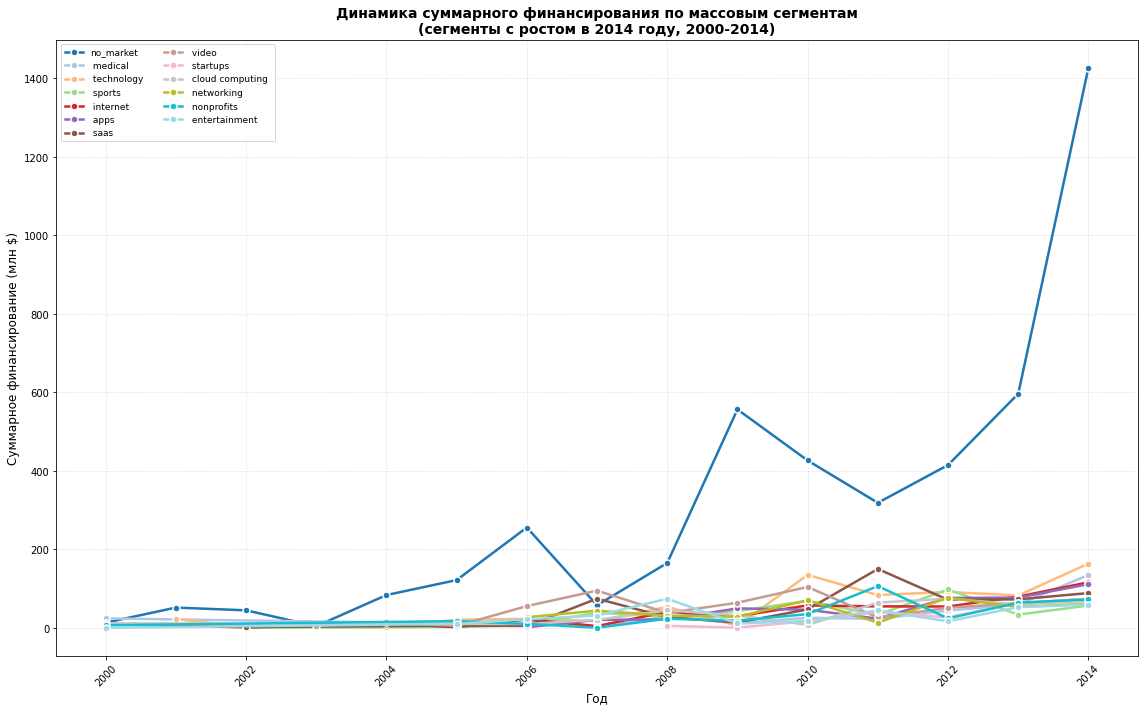

 АНАЛИЗ ТЕМПОВ РОСТА СЕГМЕНТОВ

 СЕГМЕНТЫ С НАИБОЛЕЕ БЫСТРЫМ РОСТОМ (CAGR):

  1.  entertainment 
     Среднегодовой рост (CAGR): 89.4%
     Общий рост: 59238% (2000.0 → 2014.0)
     Лет непрерывного роста: 4
     Финансирование: $0M → $59M

  2.  sports 
     Среднегодовой рост (CAGR): 75.9%
     Общий рост: 28318% (2002.0 → 2014.0)
     Лет непрерывного роста: 3
     Финансирование: $0M → $57M

  3.  apps 
     Среднегодовой рост (CAGR): 74.2%
     Общий рост: 8384% (2006.0 → 2014.0)
     Лет непрерывного роста: 3
     Финансирование: $1M → $111M

  4.  startups 
     Среднегодовой рост (CAGR): 56.4%
     Общий рост: 1364% (2008.0 → 2014.0)
     Лет непрерывного роста: 0
     Финансирование: $5M → $73M

  5.  saas 
     Среднегодовой рост (CAGR): 46.1%
     Общий рост: 4325% (2002.0 → 2014.0)
     Лет непрерывного роста: 1
     Финансирование: $2M → $89M
 ВЫВОД: СЕГМЕНТЫ С НАИБОЛЕЕ УВЕРЕННЫМ РОСТОМ


In [31]:
df_analysis = df_final.copy()

if 'funding_year' not in df_analysis.columns:
    if 'mid_funding_at' in df_analysis.columns:
        df_analysis['funding_year'] = df_analysis['mid_funding_at'].dt.year
    else:
        df_analysis['funding_year'] = df_analysis['last_funding_at'].dt.year

df_massive = df_analysis[df_analysis['market_tier'] == 'massive'].copy()

print(f"\n Количество компаний в массовых сегментах: {len(df_massive):,}")
print(f"  Количество уникальных массовых сегментов: {df_massive['market'].nunique()}")

years_range = list(range(2000, 2015))

pivot_table = df_massive.pivot_table(
    values='funding_total_usd',
    index='market',
    columns='funding_year',
    aggfunc='sum',
    fill_value=0
)

pivot_table = pivot_table[[y for y in pivot_table.columns if y in years_range]]
pivot_table_millions = pivot_table / 1e6

print("\n СВОДНАЯ ТАБЛИЦА (суммарное финансирование в млн $):")
print(pivot_table_millions.head(10).round(0).astype(int).to_string())

segments_with_growth = []

for segment in pivot_table.index:
    funding_2013 = pivot_table.loc[segment, 2013] if 2013 in pivot_table.columns else 0
    funding_2014 = pivot_table.loc[segment, 2014] if 2014 in pivot_table.columns else 0
    
    if funding_2013 > 0 and funding_2014 > funding_2013:
        growth_pct = (funding_2014 - funding_2013) / funding_2013 * 100
        segments_with_growth.append((segment, funding_2013, funding_2014, growth_pct))

segments_with_growth.sort(key=lambda x: x[3], reverse=True)


print("\n Данные для графика (млн $):")
print(growth_pivot.round(0).astype(int).to_string())

if len(growth_pivot) > 0:

    colors = plt.cm.tab20(np.linspace(0, 1, len(growth_pivot)))
    
    plt.figure(figsize=(16, 10))
    
    for i, (segment, color) in enumerate(zip(growth_pivot.index, colors)):
        values = growth_pivot.loc[segment]
        years_valid = [y for y in values.index if values[y] > 0]
        values_valid = [values[y] for y in years_valid]
        
        if len(years_valid) > 0:
            plt.plot(years_valid, values_valid, 'o-', color=color, linewidth=2.5, 
                    markersize=7, label=segment[:30], markeredgecolor='white', markeredgewidth=1.5)
    
    plt.xlabel('Год', fontsize=12)
    plt.ylabel('Суммарное финансирование (млн $)', fontsize=12)
    plt.title('Динамика суммарного финансирования по массовым сегментам\n(сегменты с ростом в 2014 году, 2000-2014)', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(range(2000, 2015, 2), rotation=45)
    
    plt.tight_layout()
    plt.show()
    

    print(" АНАЛИЗ ТЕМПОВ РОСТА СЕГМЕНТОВ")

    
    segment_growth_summary = []
    
    for segment in growth_pivot.index:
        data = growth_pivot.loc[segment]
        valid_data = data[data > 0]
        
        if len(valid_data) >= 3:
            first_val = valid_data.iloc[0]
            last_val = valid_data.iloc[-1]
            years_span = len(valid_data) - 1
            
            if first_val > 0 and years_span > 0:
                cagr = ((last_val / first_val) ** (1 / years_span) - 1) * 100
                
                # Количество лет подряд с ростом
                consecutive_growth = 0
                for i in range(1, len(valid_data)):
                    if valid_data.iloc[i] > valid_data.iloc[i-1]:
                        consecutive_growth += 1
                    else:
                        break
                

                total_growth = ((last_val / first_val) - 1) * 100
                
                segment_growth_summary.append({
                    'segment': segment,
                    'cagr': cagr,
                    'consecutive_growth': consecutive_growth,
                    'total_growth': total_growth,
                    'start_year': valid_data.index[0],
                    'end_year': valid_data.index[-1],
                    'first_val': first_val,
                    'last_val': last_val
                })
    

    segment_growth_summary.sort(key=lambda x: x['cagr'], reverse=True)
    
    print("\n СЕГМЕНТЫ С НАИБОЛЕЕ БЫСТРЫМ РОСТОМ (CAGR):")
    for i, sg in enumerate(segment_growth_summary[:5], 1):
        print(f"\n  {i}. {sg['segment']}")
        print(f"     Среднегодовой рост (CAGR): {sg['cagr']:.1f}%")
        print(f"     Общий рост: {sg['total_growth']:.0f}% ({sg['start_year']} → {sg['end_year']})")
        print(f"     Лет непрерывного роста: {sg['consecutive_growth']}")
        print(f"     Финансирование: ${sg['first_val']:.0f}M → ${sg['last_val']:.0f}M")
    

    print(" ВЫВОД: СЕГМЕНТЫ С НАИБОЛЕЕ УВЕРЕННЫМ РОСТОМ")

    
    if segment_growth_summary:
        best_segment = max(segment_growth_summary, key=lambda x: (x['cagr'], x['consecutive_growth']))
        

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Когда  будем делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавим к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.


 Доступные годы: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
  Всего записей в returns_df: 80
  Количество NaN в normalized_return: 0
  Ненулевых значений normalized_return: 76

 Пример данных returns_df (первые 20 строк):
      year    funding_type  normalized_return  total_funding  companies_with_type  total_companies
0   1999.0         venture           0.593750    141739814.0                   19               32
1   1999.0  debt_financing           0.031250       350000.0                    1               32
2   1999.0  private_equity           0.031250      3000000.0                    1               32
3   1999.0            seed           0.281250     13540493.0                    9               32
4   1999.0           angel           0.093750      1200000.0                    3               32
5   2000.0         venture           0.522388    271764752.0                   35               6

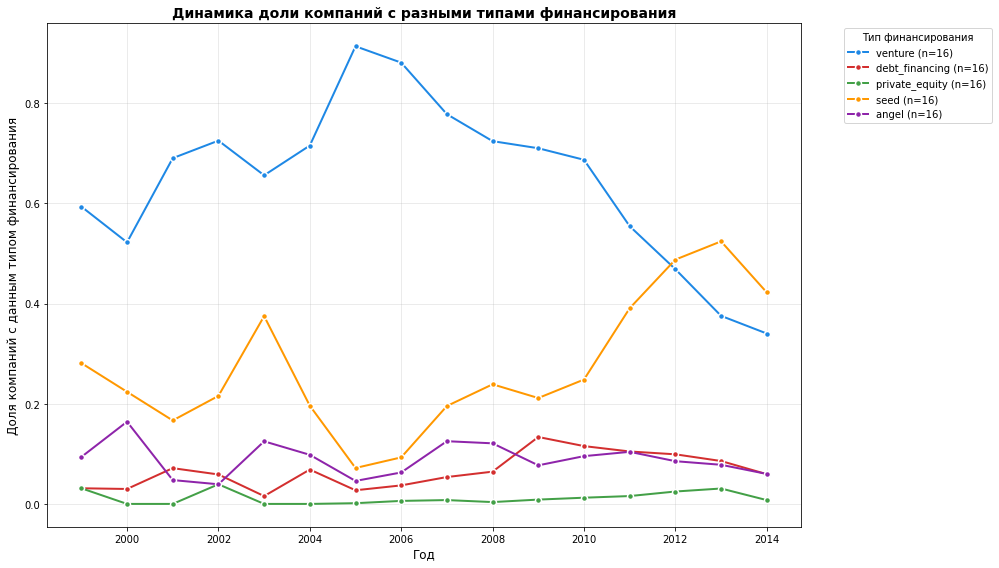

 АНАЛИЗ ДИНАМИКИ ДОЛИ КОМПАНИЙ ПО ТИПАМ ФИНАНСИРОВАНИЯ:

venture:
  Тренд: снижение
  Доля: 59.38% (1999.0) → 34.03% (2014.0)
  Изменение: -25.35%

debt_financing:
  Тренд: рост
  Доля: 3.12% (1999.0) → 5.94% (2014.0)
  Изменение: 2.81%

private_equity:
  Тренд: снижение
  Доля: 3.12% (1999.0) → 0.76% (2014.0)
  Изменение: -2.36%

seed:
  Тренд: рост
  Доля: 28.12% (1999.0) → 42.23% (2014.0)
  Изменение: 14.11%

angel:
  Тренд: снижение
  Доля: 9.38% (1999.0) → 5.99% (2014.0)
  Изменение: -3.39%

 Типы финансирования с устойчивым ростом доли компаний:
   • debt_financing
   • seed
 ОБЩАЯ СТАТИСТИКА:
  Всего записей в returns_df: 80
  Количество уникальных лет: 16


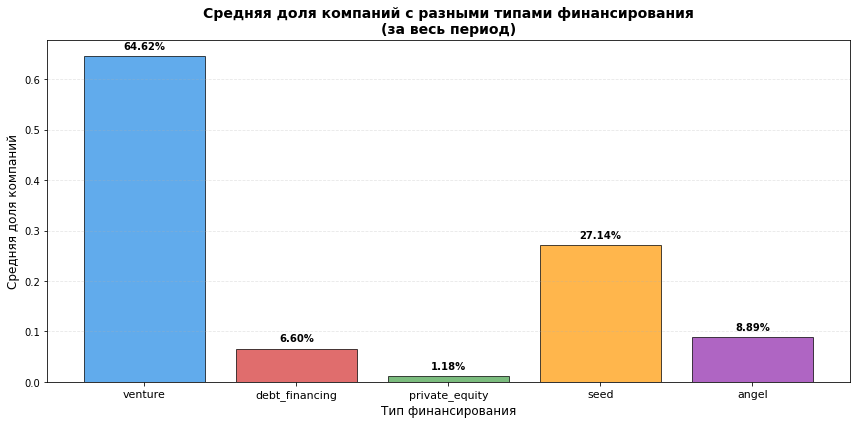

In [38]:
df_filtered = df_final.copy()

types_to_analyze = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
returns_analysis = []

if 'funding_year' not in df_filtered.columns:
    if 'mid_funding_at' in df_filtered.columns:
        df_filtered['funding_year'] = df_filtered['mid_funding_at'].dt.year
    else:
        df_filtered['funding_year'] = df_filtered['last_funding_at'].dt.year

available_years = sorted(df_filtered['funding_year'].dropna().unique())
print(f"\n Доступные годы: {available_years}")

for year in available_years:
    year_data = df_filtered[df_filtered['funding_year'] == year]
    total_companies = len(year_data)

    for funding_type in types_to_analyze:
        if funding_type in year_data.columns:
            # Считаем количество компаний, получивших финансирование данного типа
            companies_with_type = (year_data[funding_type] > 0).sum()
            # Суммируем общий объём финансирования данного типа за год
            total_funding = year_data[funding_type].sum()
        else:
            companies_with_type = 0
            total_funding = 0

        # Рассчитываем долю компаний с данным типом финансирования от общего числа компаний за год
        if total_companies > 0:
            normalized_return = companies_with_type / total_companies
        else:
            normalized_return = np.nan

        # Заменяем аномальные значения (> 200%) на NaN
        if normalized_return > 2:
            normalized_return = np.nan

        returns_analysis.append({
            'year': year,
            'funding_type': funding_type,
            'normalized_return': normalized_return,
            'total_funding': total_funding,
            'companies_with_type': companies_with_type,
            'total_companies': total_companies
        })

returns_df = pd.DataFrame(returns_analysis)

print(f"  Всего записей в returns_df: {len(returns_df)}")
print(f"  Количество NaN в normalized_return: {returns_df['normalized_return'].isna().sum()}")
print(f"  Ненулевых значений normalized_return: {(returns_df['normalized_return'] > 0).sum()}")

print("\n Пример данных returns_df (первые 20 строк):")
print(returns_df.head(20).to_string())

plt.figure(figsize=(14, 8))

colors = {
    'venture': '#1E88E5',
    'debt_financing': '#D32F2F',
    'private_equity': '#43A047',
    'seed': '#FF9800',
    'angel': '#8E24AA'
}

for funding_type in types_to_analyze:
    data = returns_df[returns_df['funding_type'] == funding_type].sort_values('year')
    valid_data = data.dropna(subset=['normalized_return'])
    if len(valid_data) > 0:
        plt.plot(
            valid_data['year'],
            valid_data['normalized_return'],
            label=f"{funding_type} (n={len(valid_data)})",
            color=colors.get(funding_type, '#333'),
            marker='o',
            linewidth=2,
            markersize=6,
            markeredgecolor='white',
            markeredgewidth=1.5)

plt.title('Динамика доли компаний с разными типами финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля компаний с данным типом финансирования', fontsize=12)
plt.legend(
    title='Тип финансирования',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" АНАЛИЗ ДИНАМИКИ ДОЛИ КОМПАНИЙ ПО ТИПАМ ФИНАНСИРОВАНИЯ:")

trend_summary = {}

for funding_type in types_to_analyze:
    data = returns_df[returns_df['funding_type'] == funding_type].sort_values('year')
    valid_data = data.dropna(subset=['normalized_return'])

    if len(valid_data) >= 2:
        start_return = valid_data['normalized_return'].iloc[0]
        end_return = valid_data['normalized_return'].iloc[-1]
        start_year = valid_data['year'].iloc[0]
        end_year = valid_data['year'].iloc[-1]

        if end_return > start_return:
            trend = "рост"
        elif end_return < start_return:
            trend = "снижение"
        else:
            trend = "стабильность"

        trend_summary[funding_type] = trend
        print(f"\n{funding_type}:")
        print(f"  Тренд: {trend}")
        print(f"  Доля: {start_return:.2%} ({start_year}) → {end_return:.2%} ({end_year})")
        print(f"  Изменение: {(end_return - start_return):.2%}")
    else:
        trend_summary[funding_type] = "недостаточно данных"
        print(f"\n{funding_type}: недостаточно данных для анализа тренда")

best_growth = [k for k, v in trend_summary.items() if "рост" in v]
if best_growth:
    print(f"\n Типы финансирования с устойчивым ростом доли компаний:")
    for ft in best_growth:
        print(f"   • {ft}")
else:
    print("\n Не выявлено типов финансирования с устойчивым ростом доли компаний.")


print(" ОБЩАЯ СТАТИСТИКА:")
print(f"  Всего записей в returns_df: {len(returns_df)}")
print(f"  Количество уникальных лет: {returns_df['year'].nunique()}")

plt.figure(figsize=(12, 6))

mean_drops = []
for funding_type in types_to_analyze:
    data = returns_df[returns_df['funding_type'] == funding_type]['normalized_return'].dropna()
    if len(data) > 0:
        mean_drops.append(data.mean())
    else:
        mean_drops.append(0)

x_pos = np.arange(len(types_to_analyze))
bars = plt.bar(x_pos, mean_drops, color=[colors.get(ft, '#333') for ft in types_to_analyze], 
               edgecolor='black', alpha=0.7)

plt.xlabel('Тип финансирования', fontsize=12)
plt.ylabel('Средняя доля компаний', fontsize=12)
plt.title('Средняя доля компаний с разными типами финансирования\n(за весь период)', 
          fontsize=14, fontweight='bold')
plt.xticks(x_pos, types_to_analyze, fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, mean in zip(bars, mean_drops):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mean:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



## Шаг 5. Итоговый вывод и рекомендации

Был проведен анализ динамики финансирования по массовым сегментам рынка,отбораны сегменты с ростом > 10 % за 2014 и 2013. Построены графики финансирования для лидеров роста,проведен анализ доли компаний по типам финансирования (venture, debt_financing, private_equity, seed, angel).

1. По количеству компаний лидирует: Единичное финансирование (58.9%) По объему инвестиций доминирует: Срок финансирования более года (61.9%) Группа 'Единичное финансирование' лидирует по числу компаний, но не по объему инвестиций Группа 'Срок финансирования более года' привлекает больше средств при меньшем количестве компаний;
2. Большинство сегментов (714 из 849, 84.1%) являются нишевыми, однако именно массовые сегменты (всего 54 сегментов) концентрируют 81.5% всех компаний, а средние сегменты составляют 81 сегментов и содержат 12.4% компаний.
3. Сегмент с НАИБОЛЬШЕЙ долей аномального финансирования: real estate : 17.9% компаний (45.0 из 251.0). 
Другие сегменты в топ-3: 2. technology: 16.2%; 3. search: 16.1%; 
По категориям сегментов: Массовый сегмент: 12.3% компаний с аномальным финансированием; Средний сегмент: 14.1% компаний с аномальным финансированием; Нишевый сегмент: 15.1% компаний с аномальным финансированием.
4. Популярность: 
ЧАСТО ИСПОЛЬЗУЕМЫЕ, НО С НЕБОЛЬШИМ ОБЪЕМОМ - grant (1898.2 M, 1,000 компаний)
РЕДКО ИСПОЛЬЗУЕМЫЕ, НО С БОЛЬШИМ ОБЪЕМОМ - private_equity (3158.2M, 586 компаний)
ЧАСТО ИСПОЛЬЗУЕМЫЕ И С БОЛЬШИМ ОБЪЕМОМ (лидеры): 
• venture:  $ 104909.9𝑀,18,635 компаний

• seed: $ 9572.2M, 13,468 компаний

• debt_financing:  $ 5708.4𝑀,3,050 компаний

• angel: $ 2600.7M, 2,985 компаний 

• undisclosed: $ 2199.7M, 831 компаний

ЛИДЕРЫ ПО ОБЪЕМУ И ПОПУЛЯРНОСТИ: venture, seed, debt_financing, angel, undisclosed

5. Тенденция, которая наблюдалась в 2014 году по количеству раундов и средств: 
-Размер раунда: повышалась ( 0.56𝑀→ 0.60M) 
-Количество раундов: понижалась (12,808.0 → 7,236.0)
Итог: 2014 год: размер раундов рос, но активность на рынке снижалась.

Лидирующие типы финансирования с устойчивым ростом доли компаний:
   1. debt_financing
   2. seed